In [1]:
import pandas as pd

email_batch_1 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Email Qwen Priority Dataset/email_batch_1_priority_qwen2.5.csv')
email_batch_2 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Email Qwen Priority Dataset/email_batch_2_priority_qwen2.5.csv')
email_synthetic_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Priority Modeling/cleaned_priority_synthetic_balanced_full_dataset.csv')

original_data = pd.concat([email_batch_1, email_batch_2], ignore_index=True)
email_data = pd.concat([email_batch_1, email_batch_2, email_synthetic_data], ignore_index=True)

In [2]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118196 entries, 0 to 118195
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   From             118196 non-null  object
 1   To               116013 non-null  object
 2   Subject          118196 non-null  object
 3   Message          118196 non-null  object
 4   Day              118196 non-null  object
 5   Date & Time      118196 non-null  object
 6   url_count        118196 non-null  int64 
 7   Cleaned_Subject  117351 non-null  object
 8   Cleaned_Message  118083 non-null  object
 9   Combined_Text    118196 non-null  object
 10  Subject_LLM      118149 non-null  object
 11  Message_LLM      118172 non-null  object
 12  Email_Priority   118196 non-null  object
dtypes: int64(1), object(12)
memory usage: 11.7+ MB


In [2]:
email_data = email_data.drop(columns=['From', 'To', 'Day', 'Date & Time', 'Subject', 'Day', 'Date & Time'])

In [3]:
email_data = email_data.drop(columns=['Message', 'url_count'])
#Cleaned_Subject', 'Combined_Text'

In [ ]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241774 entries, 0 to 241773
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Cleaned_Subject   226956 non-null  object
 1   Cleaned_Message   241774 non-null  object
 2   Combined_Text     241774 non-null  object
 3   Qwen2.5_Category  241774 non-null  object
dtypes: object(4)
memory usage: 7.4+ MB


## Data Exploration

In [4]:
email_data['Email_Priority'].value_counts()

Email_Priority
Medium    39432
Low       39432
High      39332
Name: count, dtype: int64

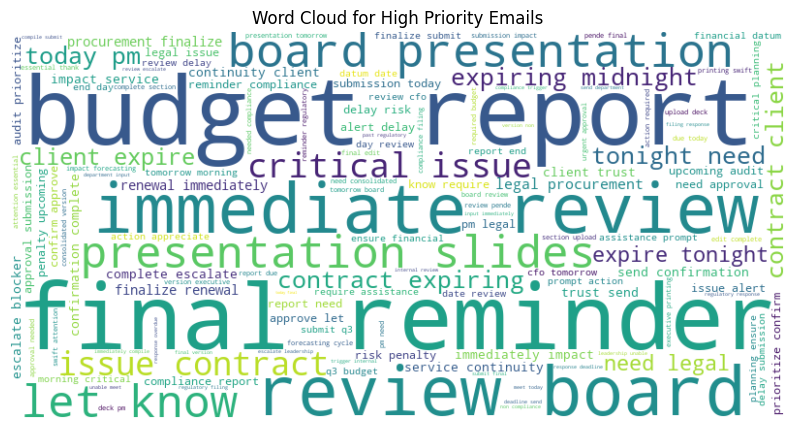

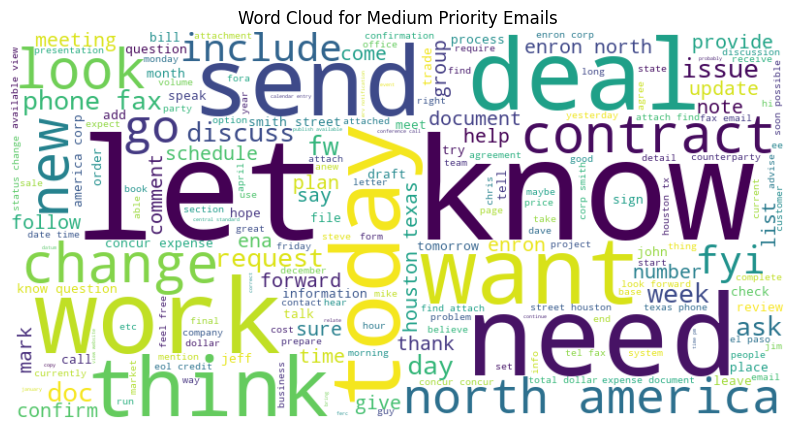

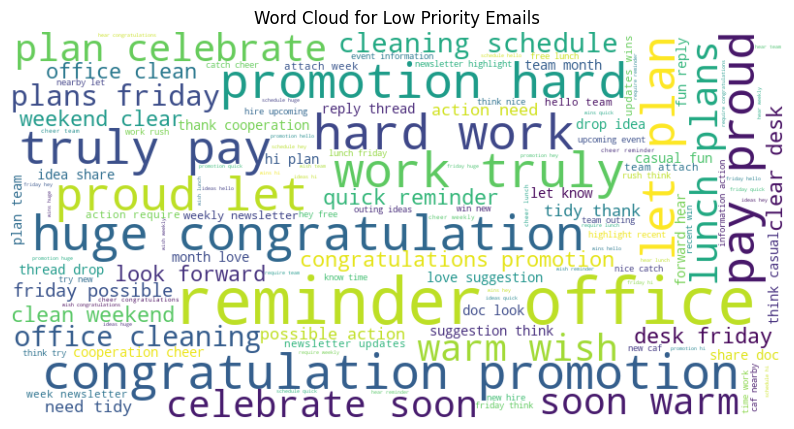

In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## High Priority
high_emails = email_data[email_data['Email_Priority'] == 'High']
text = " ".join(str(msg) for msg in high_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for High Priority Emails")
plt.show()

## Medium Priority
medium_emails = email_data[email_data['Email_Priority'] == 'Medium']
text = " ".join(str(msg) for msg in medium_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Medium Priority Emails")
plt.show()

## Low Priority
low_emails = email_data[email_data['Email_Priority'] == 'Low']
text = " ".join(str(msg) for msg in low_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Low Priority Emails")
plt.show()

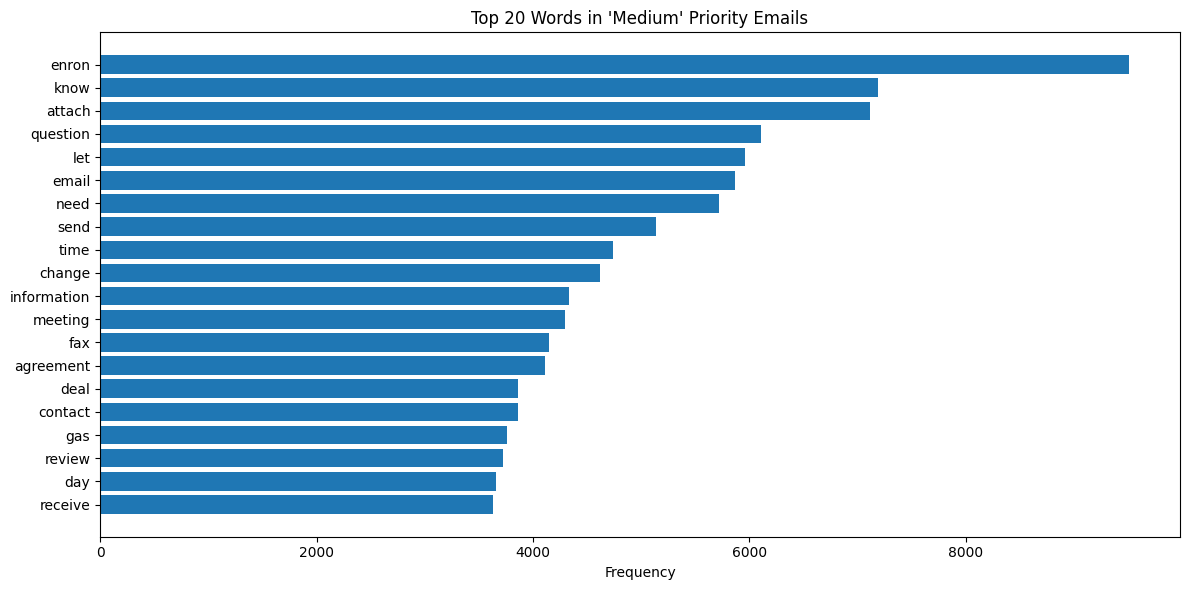

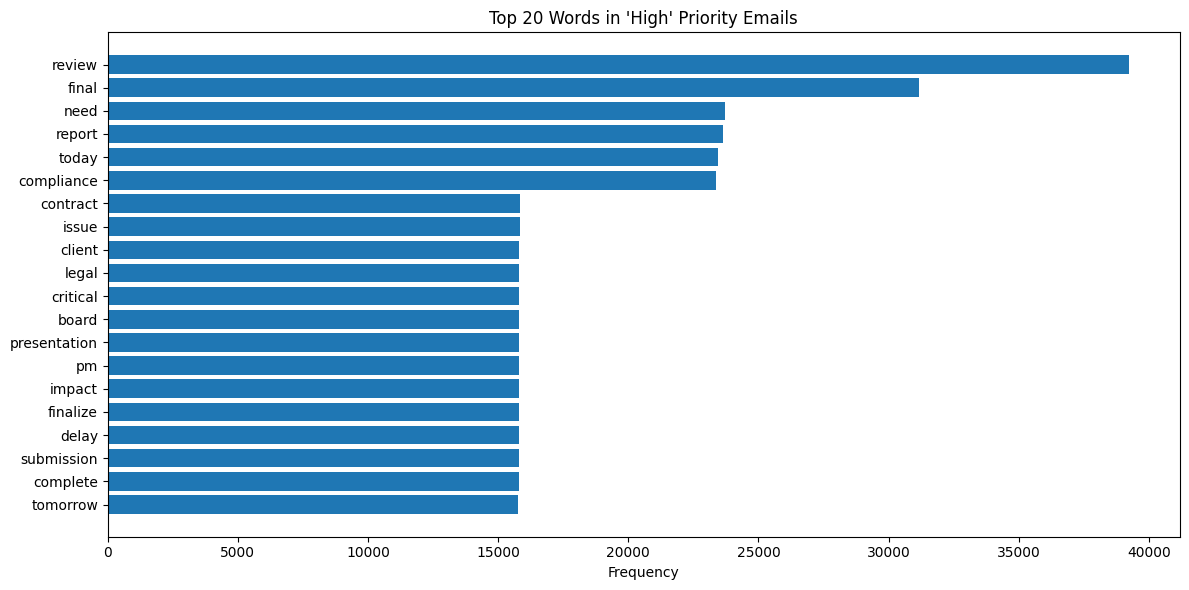

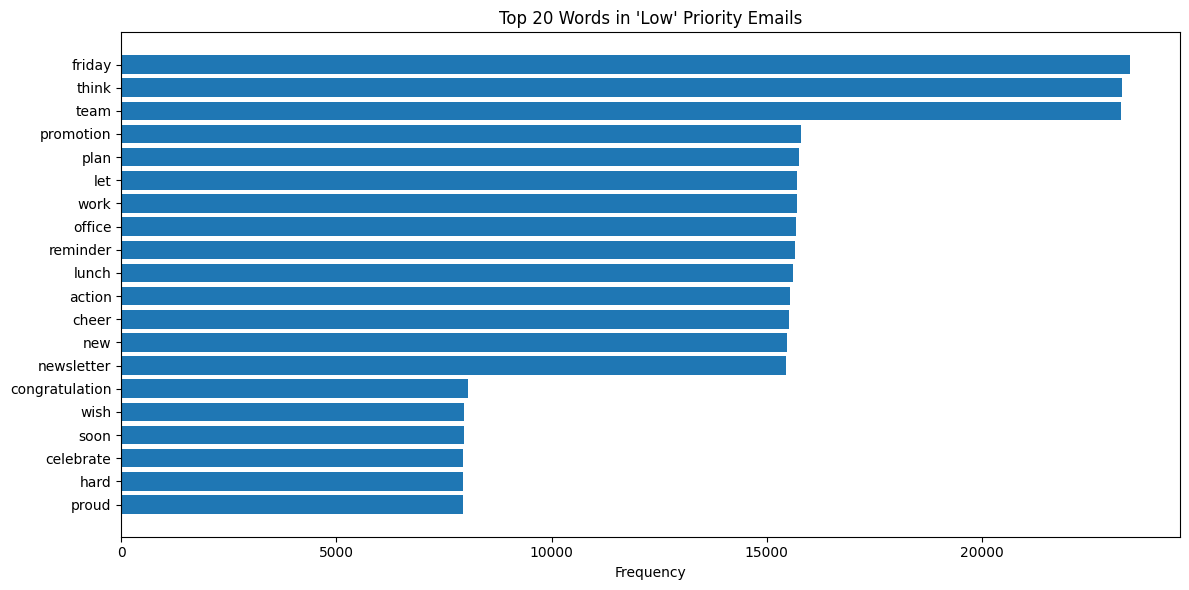

In [6]:
from collections import Counter
import matplotlib.pyplot as plt

categories = email_data['Email_Priority'].unique()

for category in categories:
    category_emails = email_data[email_data['Email_Priority'] == category]
    
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())
    words = text.split()
    
    word_freq = Counter(words)
    top_words = word_freq.most_common(20)
    
    if not top_words:
        continue

    labels, values = zip(*top_words)

    plt.figure(figsize=(12, 6))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Words in '{category}' Priority Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [7]:
email_data['Combined_Text'] = email_data['Combined_Text'].fillna("")
email_data['Text_Length'] = email_data['Combined_Text'].apply(len)

print("Text Length Statistics:")
print(email_data['Text_Length'].describe())

Text Length Statistics:
count    118196.000000
mean        181.869793
std          84.884645
min           2.000000
25%         122.000000
50%         182.000000
75%         221.000000
max         500.000000
Name: Text_Length, dtype: float64


   Text_Length  Log_Body_Length
0          482         6.180017
1          482         6.180017
2          482         6.180017
3          482         6.180017
4          117         4.770685


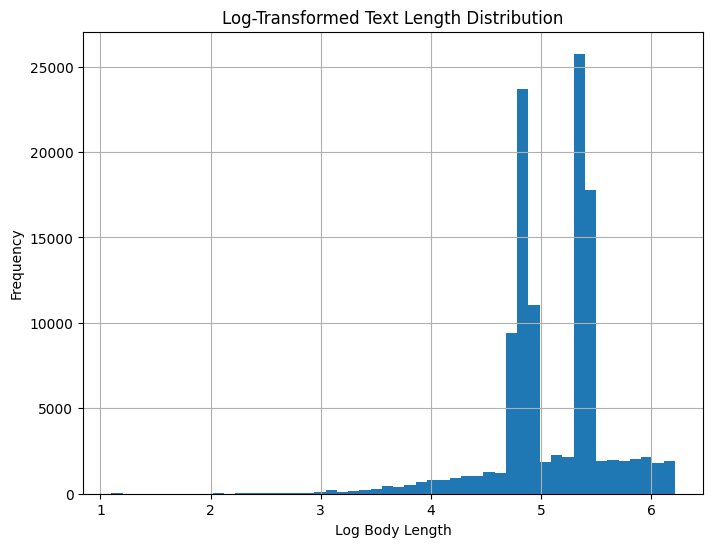

In [8]:
#Log Transformation
import numpy as np

email_data['Log_Body_Length'] = np.log1p(email_data['Text_Length'])  # log(1 + x) to handle 0s

print(email_data[['Text_Length', 'Log_Body_Length']].head())

email_data['Log_Body_Length'].hist(bins=50, figsize=(8, 6))
plt.title('Log-Transformed Text Length Distribution')
plt.xlabel('Log Body Length')
plt.ylabel('Frequency')
plt.show()

   Text_Length  Scaled_Body_Length
0          482            0.963855
1          482            0.963855
2          482            0.963855
3          482            0.963855
4          117            0.230924


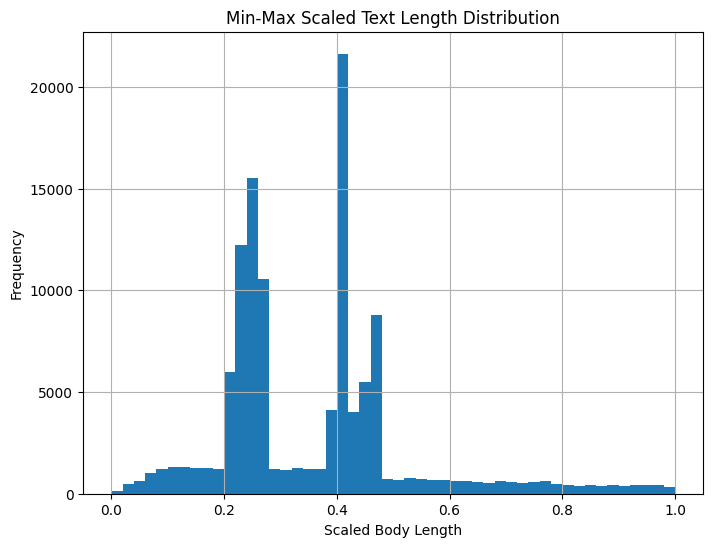

In [9]:
#Scaling (Min-Max Scaling)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

email_data['Scaled_Body_Length'] = scaler.fit_transform(email_data[['Text_Length']])

print(email_data[['Text_Length', 'Scaled_Body_Length']].head())

email_data['Scaled_Body_Length'].hist(bins=50, figsize=(8, 6))
plt.title('Min-Max Scaled Text Length Distribution')
plt.xlabel('Scaled Body Length')
plt.ylabel('Frequency')
plt.show()

   Text_Length  Standardized_Body_Length
0          482                  3.535757
1          482                  3.535757
2          482                  3.535757
3          482                  3.535757
4          117                 -0.764214


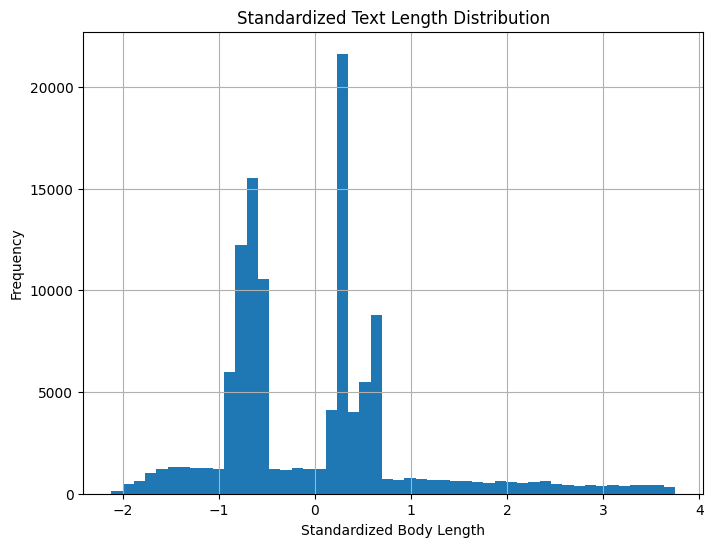

In [10]:
#Standardization (Z-Score)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

email_data['Standardized_Body_Length'] = scaler.fit_transform(email_data[['Text_Length']])

print(email_data[['Text_Length', 'Standardized_Body_Length']].head())

email_data['Standardized_Body_Length'].hist(bins=50, figsize=(8, 6))
plt.title('Standardized Text Length Distribution')
plt.xlabel('Standardized Body Length')
plt.ylabel('Frequency')
plt.show()

In [11]:
email_data = email_data.drop(columns=['Text_Length', 'Log_Body_Length', 'Scaled_Body_Length', 'Standardized_Body_Length'])

In [12]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 'url_count',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM', 'Email_Priority'],
      dtype='object')

In [13]:
email_data['Email_Priority'].value_counts()

Email_Priority
Medium    39432
Low       39432
High      39332
Name: count, dtype: int64

## Model Building - Linear Regression

#(1) TfidfVectorizer - Unigram - Linear Regression - Cleaned_Message | Acc: 99%

Column: Cleaned_Message
LR: 1U - Max:5000 - Classification Report:
Accuracy: 0.9950930626057529
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



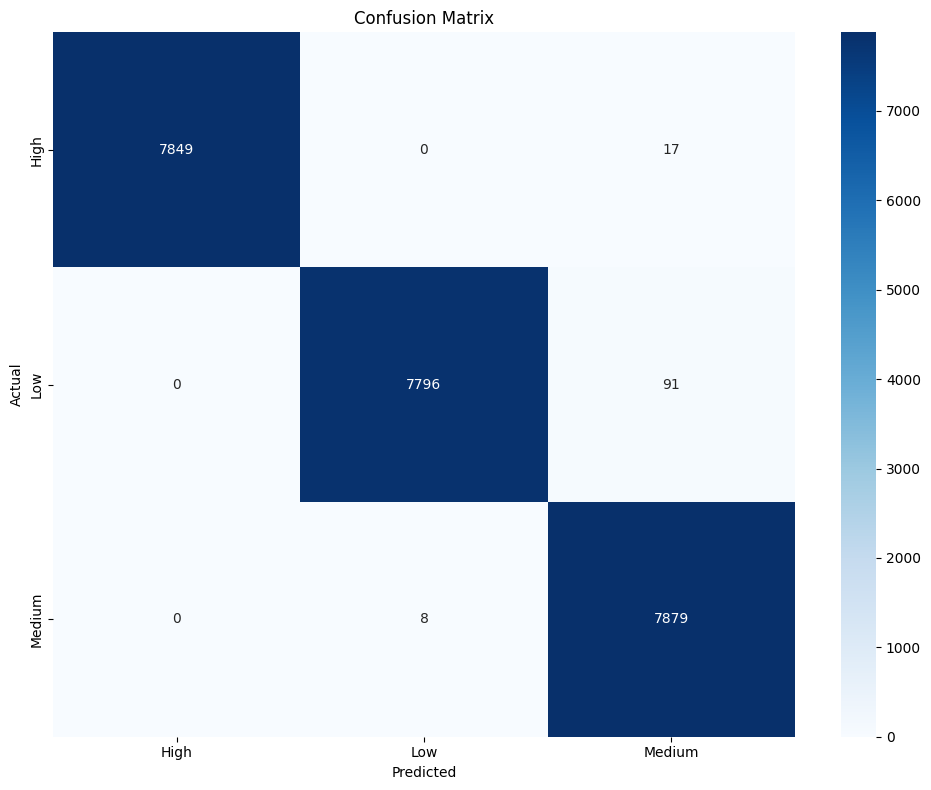

✅ Model saved successfully.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 1U - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(2) TfidfVectorizer - Bigram - Linear Regression - Cleaned_Message | Acc: 99%

Column: Cleaned_Message
LR: 2B - Max:5000 - Classification Report:
Accuracy: 0.9950084602368866
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



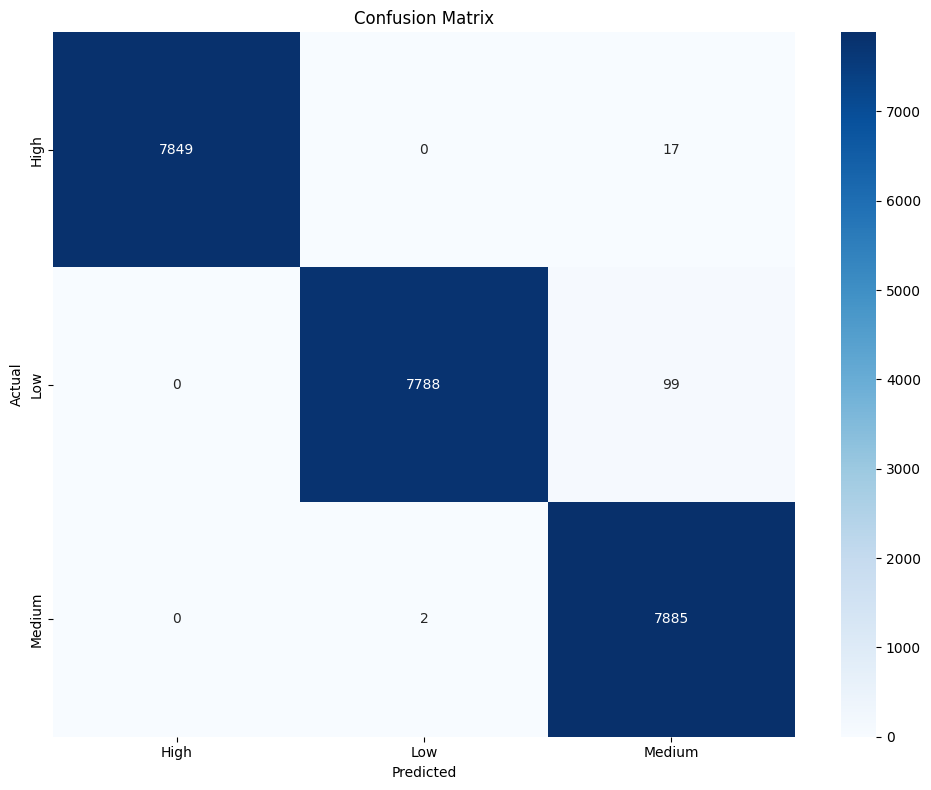

✅ Model saved successfully.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 2B - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(3) TfidfVectorizer - Uni,Bigram - Linear Regression - Cleaned_Message | Acc: 99%

Column: Cleaned_Message
LR: 1U,2B - Max:5000 - Classification Report:
Accuracy: 0.9951353637901861
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



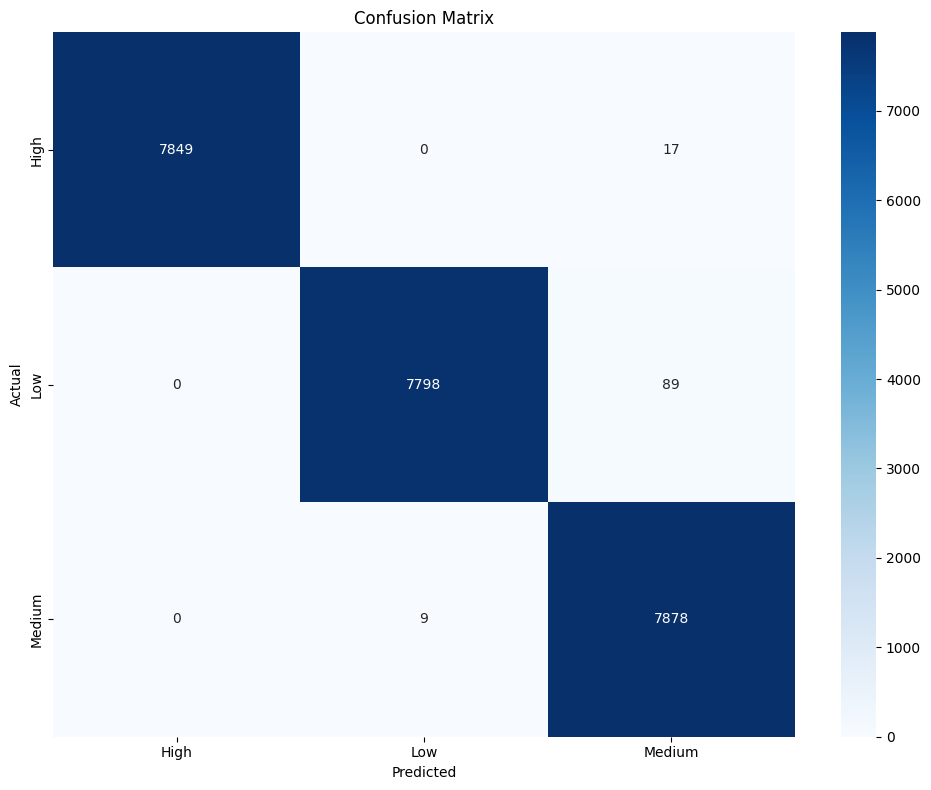

✅ Model saved successfully.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 1U,2B - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(4) TfidfVectorizer - Uni,Bi,Trigram - Linear Regression - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
LR: 1,3 UBT - Max:8000 - Classification Report:
Accuracy: 0.9949661590524534
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           0.99     23640
   macro avg       1.00      0.99      0.99     23640
weighted avg       1.00      0.99      0.99     23640



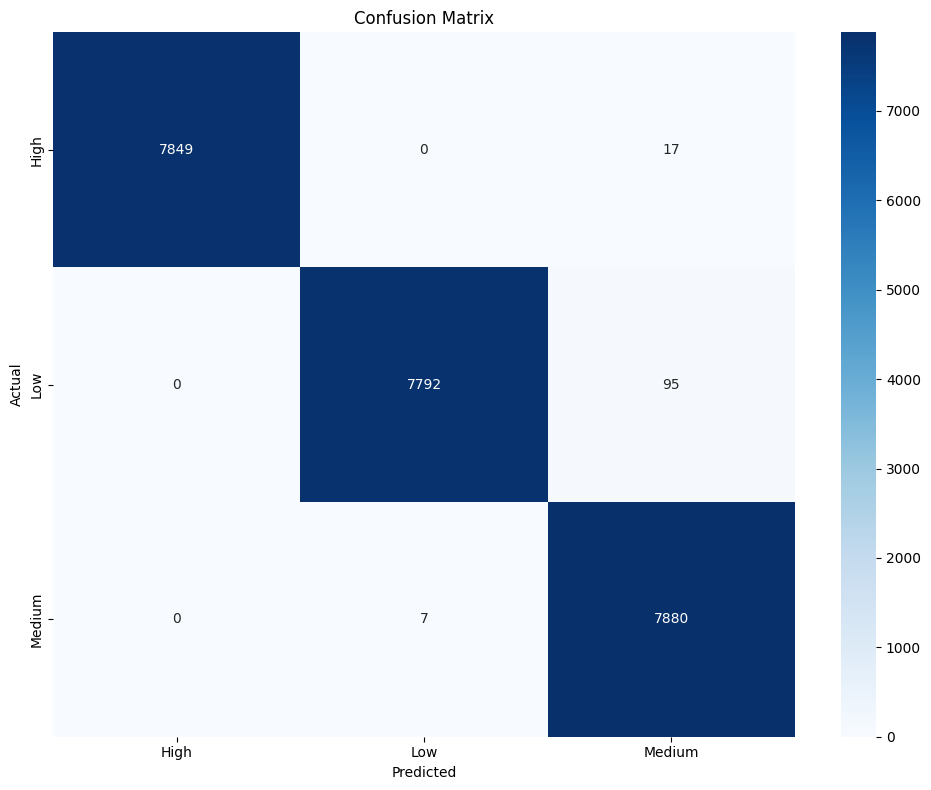

✅ Model saved successfully.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"LR: 1,3 UBT - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

---------------------------------------------------------------------------------

## Model Building - Random Forest

#(1) TfidfVectorizer - Unigram - Random Forest - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
RF: 1,1 U - Max:5000 - Classification Report:
Accuracy: 0.9946700507614213
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           0.99     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       0.99      0.99      0.99     23640



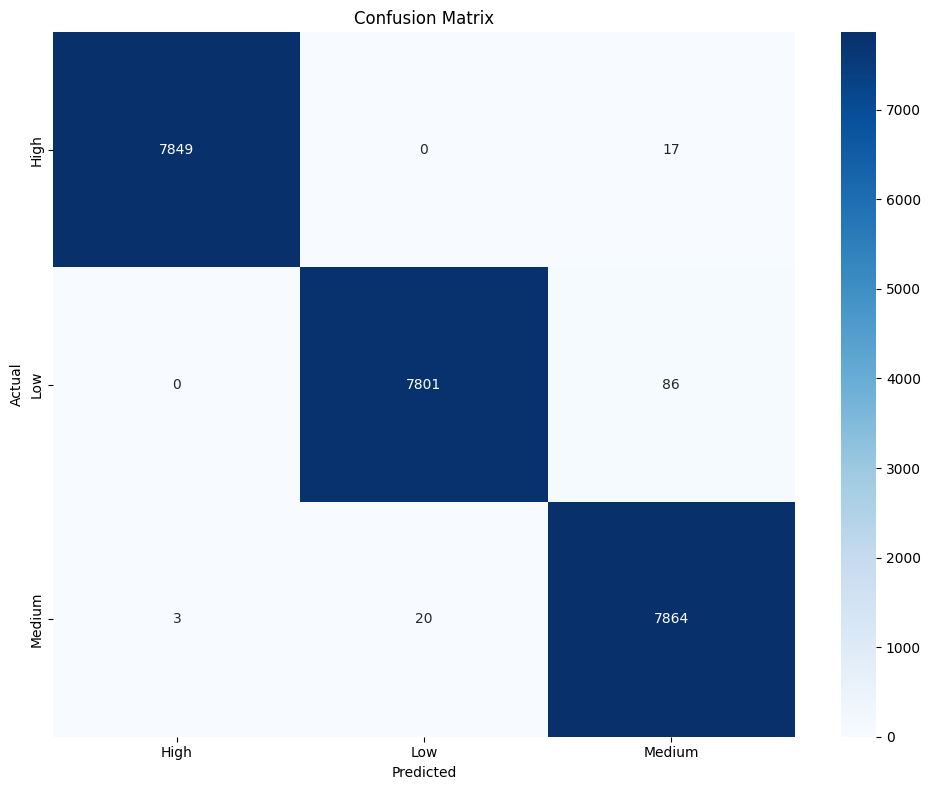

✅ Model saved successfully.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"RF: 1,1 U - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(2) TfidfVectorizer - Bigram - Random Forest - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
RF: 1,1 U - Max:5000 - Classification Report:
Accuracy: 0.9946277495769882
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           0.99     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       0.99      0.99      0.99     23640



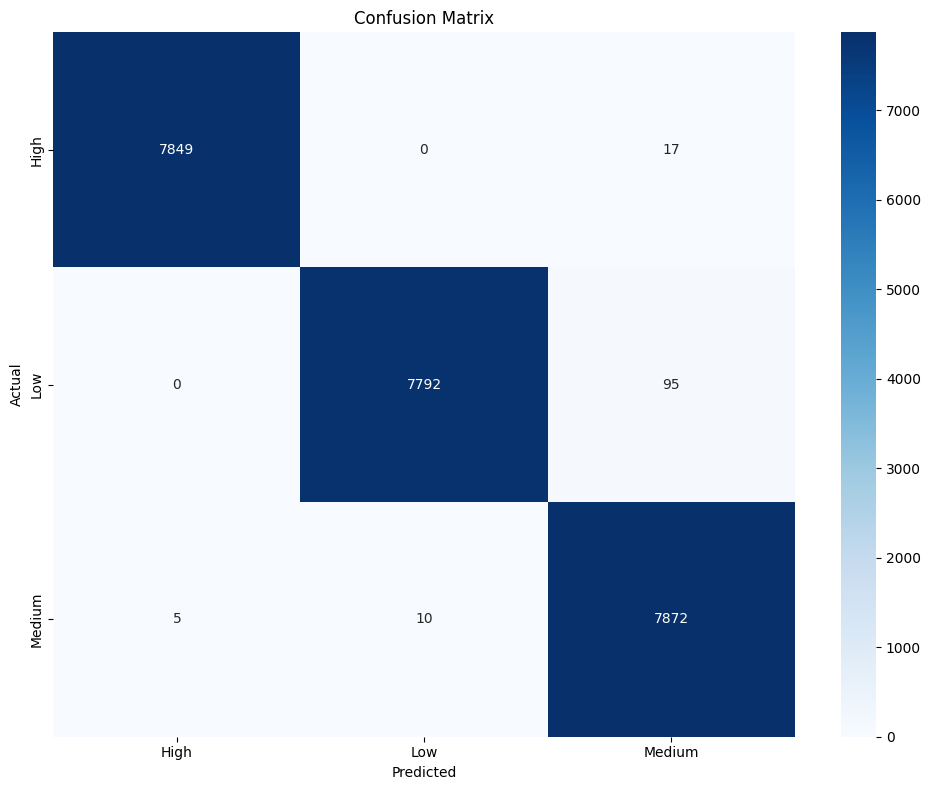

✅ Model saved successfully.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"RF: 1,1 U - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(3) TfidfVectorizer - Uni,Bigram - Random Forest - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
RF: 1,2 UBT - Max:5000 - Classification Report:
Accuracy: 0.9950507614213198
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



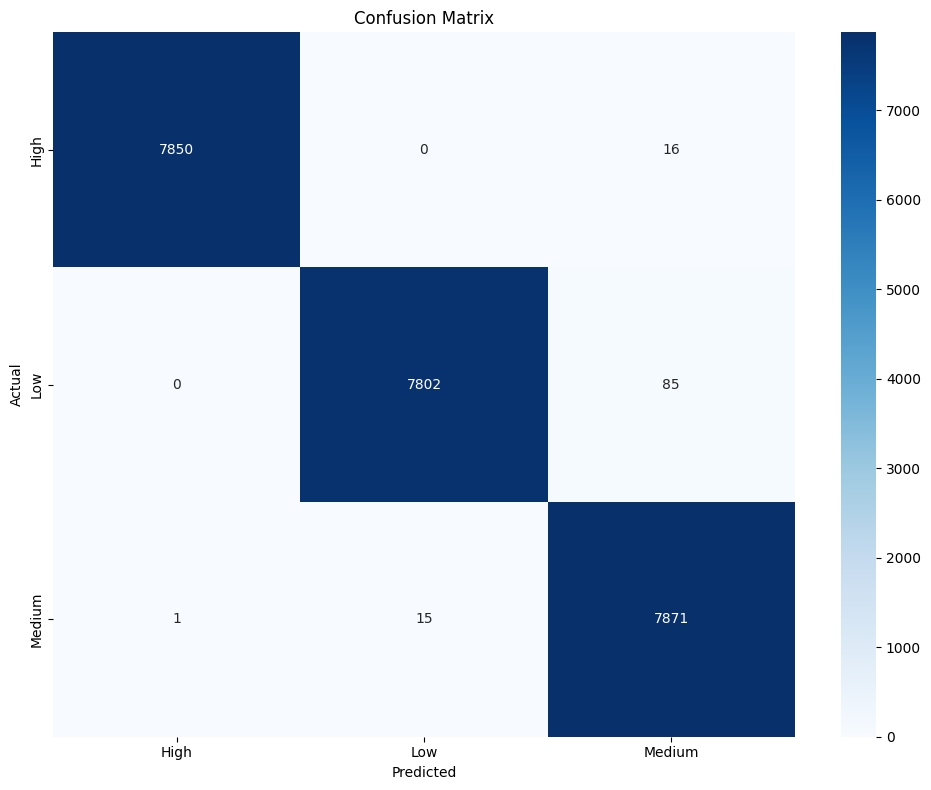

✅ Model saved successfully.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"RF: 1,2 UBT - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(4) TfidfVectorizer - Uni,Bi, Trigram - Random Forest - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
RF: 1,2 UBT - Max:5000 - Classification Report:
Accuracy: 0.9952199661590525
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



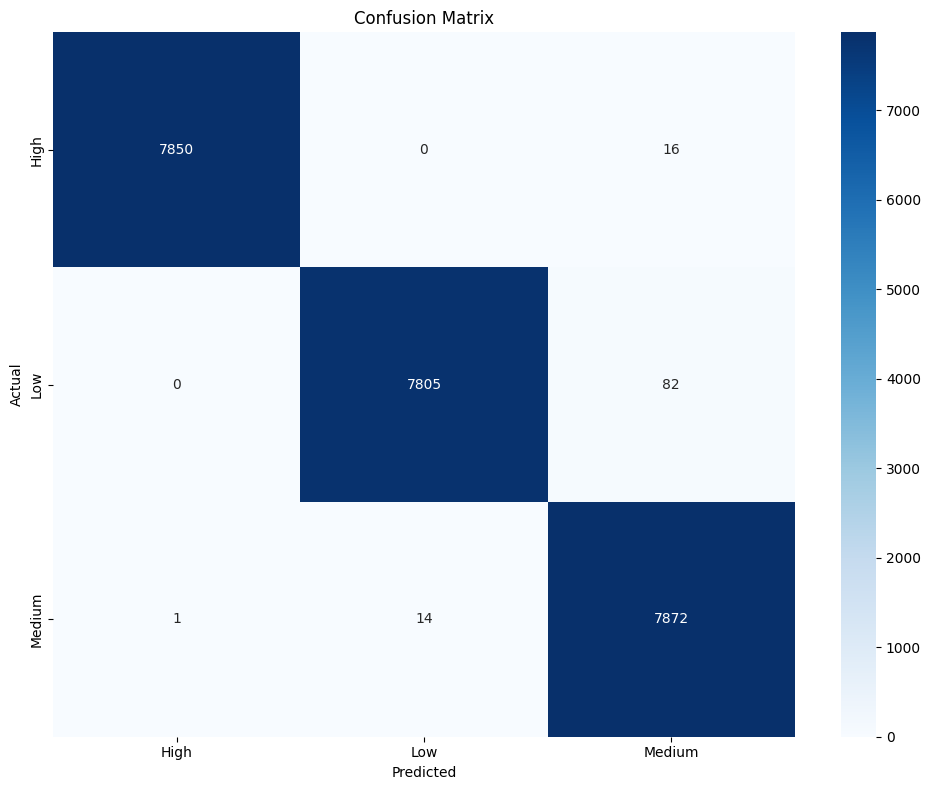

✅ Model saved successfully.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection top 1000 features using chi2
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_selected, y_train)

#Predict & Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"RF: 1,2 UBT - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

## Model Building - SVM

#(3) TfidfVectorizer - Uni,Bigram - SVM - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
SVM: 1,2 UB - Max:5000 - Classification Report:
Accuracy: 0.9950930626057529
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



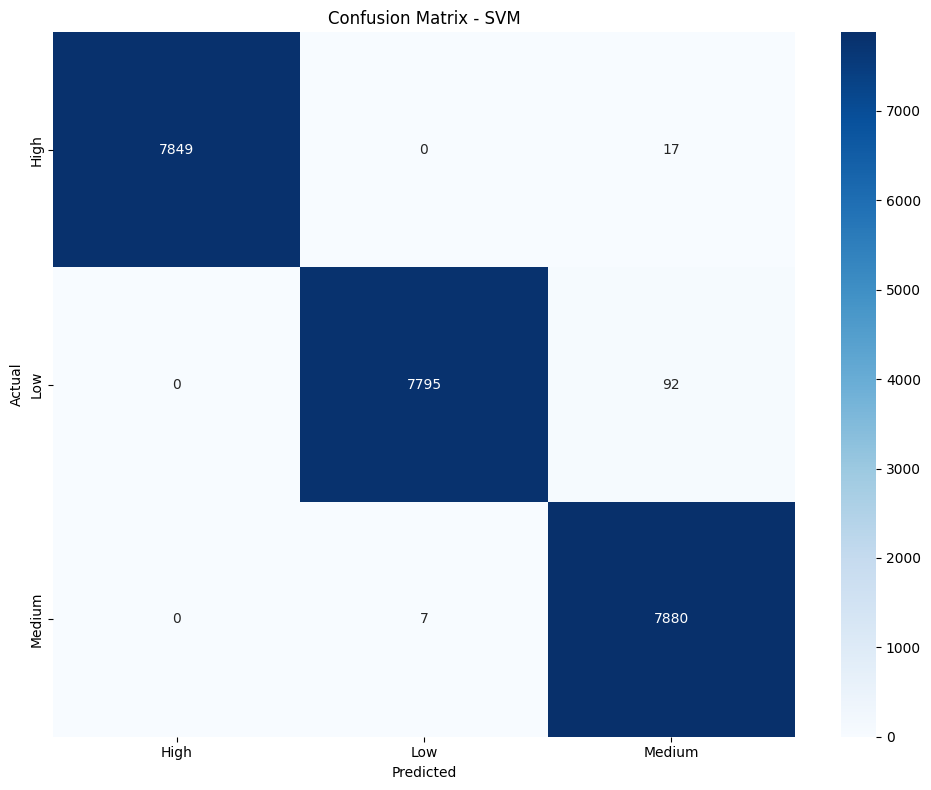

✅ Model saved successfully.


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train SVM classifier
model = LinearSVC(class_weight='balanced', max_iter=2000)
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"SVM: 1,2 UB - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(4) TfidfVectorizer - Uni,Bi, Trigram - SVM - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
SVM: 1,3 UBT - Max:5000 - Classification Report:
Accuracy: 0.9952199661590525
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



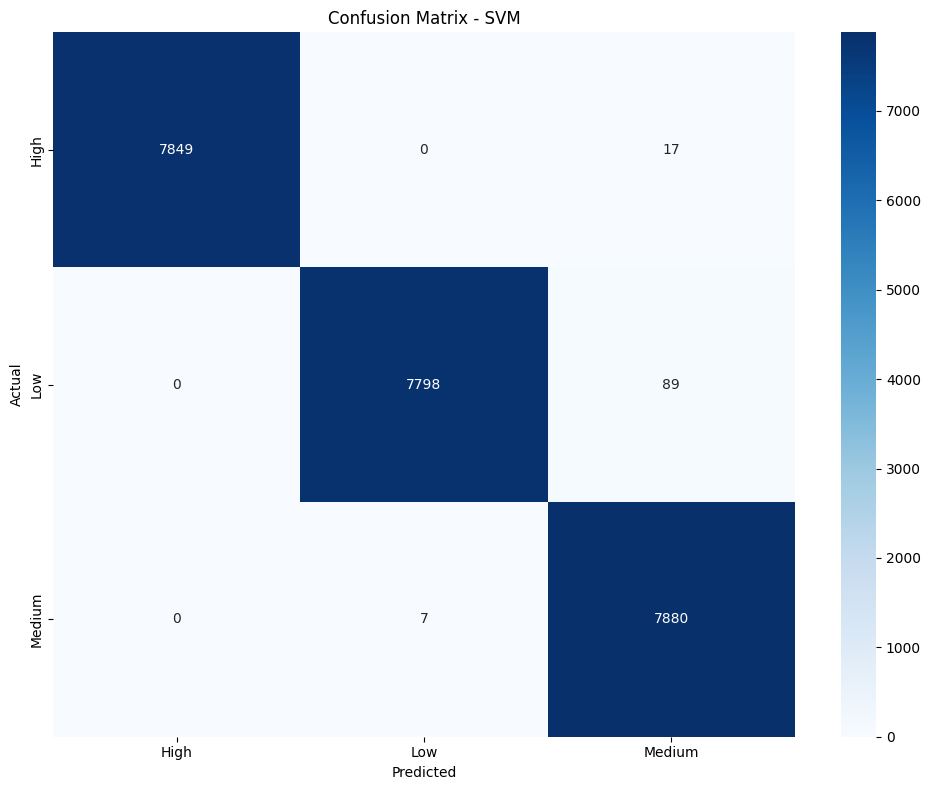

✅ Model saved successfully.


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train SVM classifier
model = LinearSVC(class_weight='balanced', max_iter=2000)
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"SVM: 1,3 UBT - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

## Model Building - Naive Bayes

#(1) TfidfVectorizer - Unigram - NB - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
NB: 1,1 U - Max:5000 - Classification Report:
Accuracy: 0.9925549915397631
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       0.99      0.99      0.99      7887
      Medium       0.99      0.99      0.99      7887

    accuracy                           0.99     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       0.99      0.99      0.99     23640



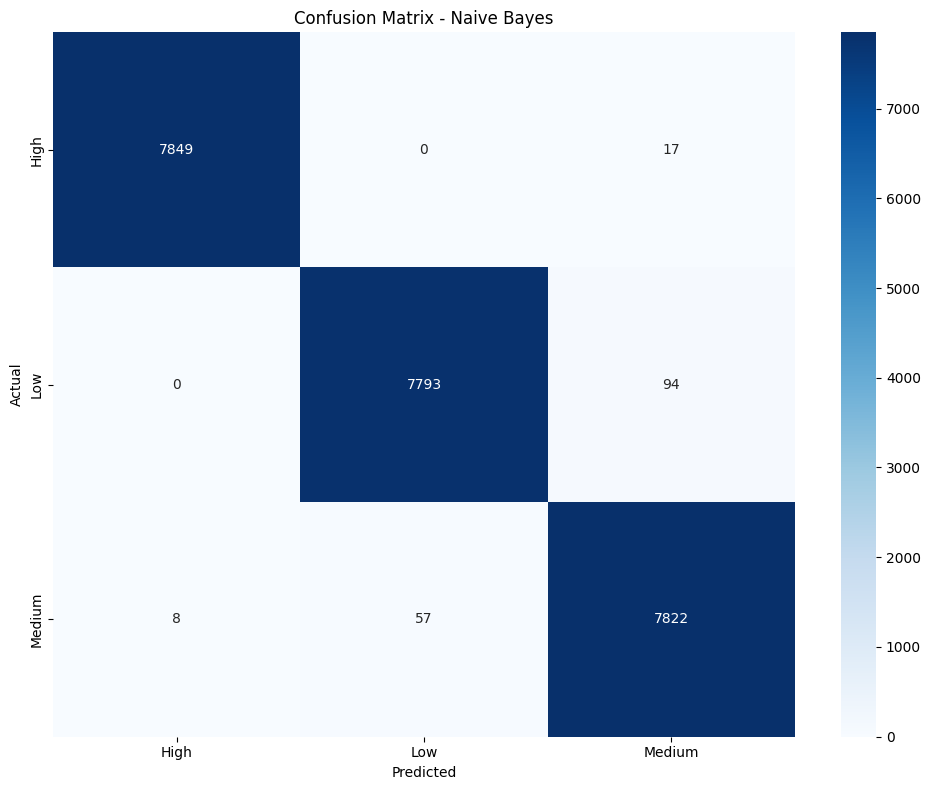

✅ Model saved successfully.


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 1,1 U - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(2) TfidfVectorizer - Bigram - NB - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
NB: 2,2 B - Max:5000 - Classification Report:
Accuracy: 0.9004230118443316
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       0.77      1.00      0.87      7887
      Medium       0.99      0.71      0.83      7887

    accuracy                           0.90     23640
   macro avg       0.92      0.90      0.90     23640
weighted avg       0.92      0.90      0.90     23640



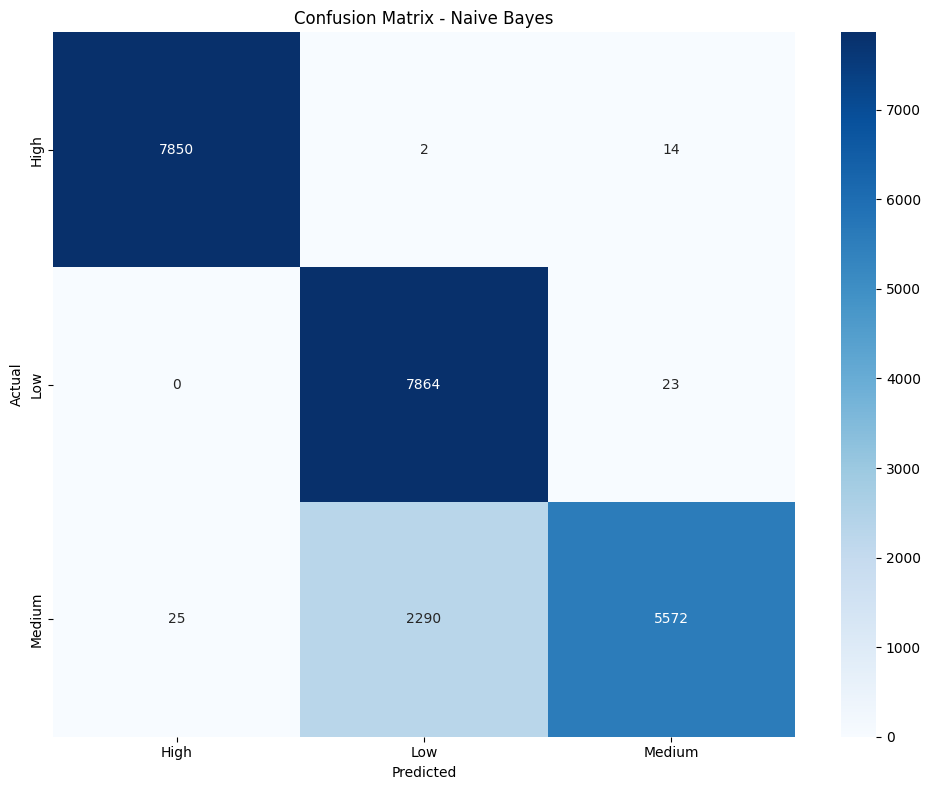

✅ Model saved successfully.


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 2,2 B - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(3) TfidfVectorizer - Uni,Bigram - NB - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
NB: 1,2 UB - Max:5000 - Classification Report:
Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       0.99      0.99      0.99      7887
      Medium       0.99      0.99      0.99      7887

    accuracy                           0.99     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       0.99      0.99      0.99     23640



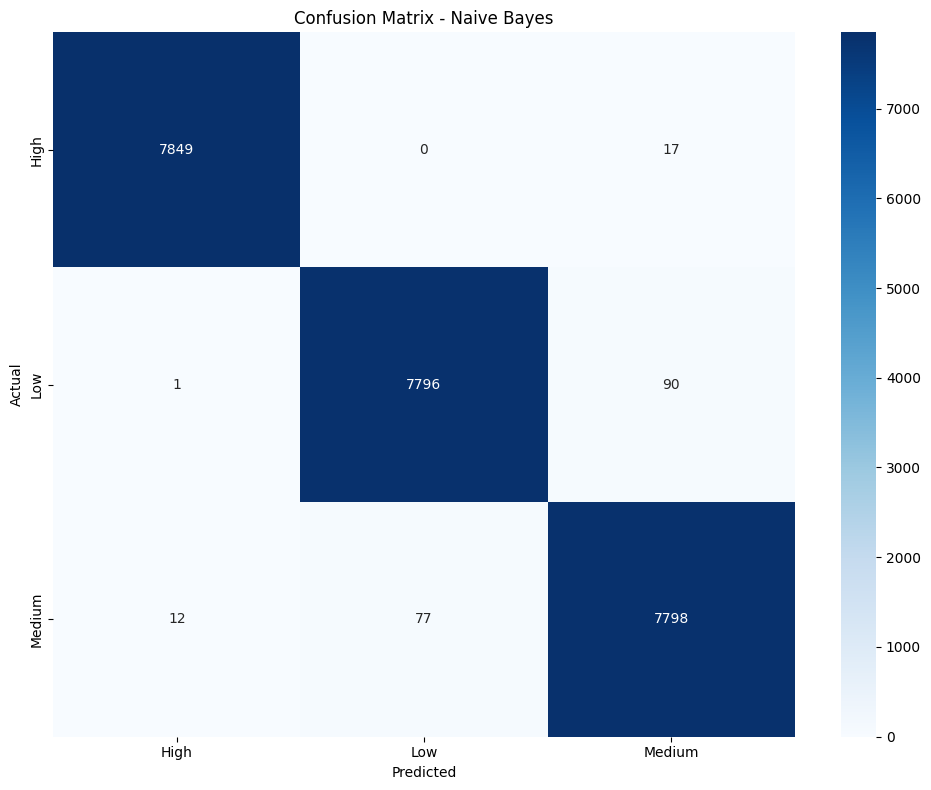

✅ Model saved successfully.


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 1,2 UB - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

#(4) TfidfVectorizer - Uni,Bi, Trigram - NB - Cleaned_Message - Acc: 99%

Column: Cleaned_Message
NB: 1,3 UBT - Max:5000 - Classification Report:
Accuracy: 0.988409475465313
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       0.98      0.99      0.99      7887
      Medium       0.99      0.98      0.98      7887

    accuracy                           0.99     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       0.99      0.99      0.99     23640



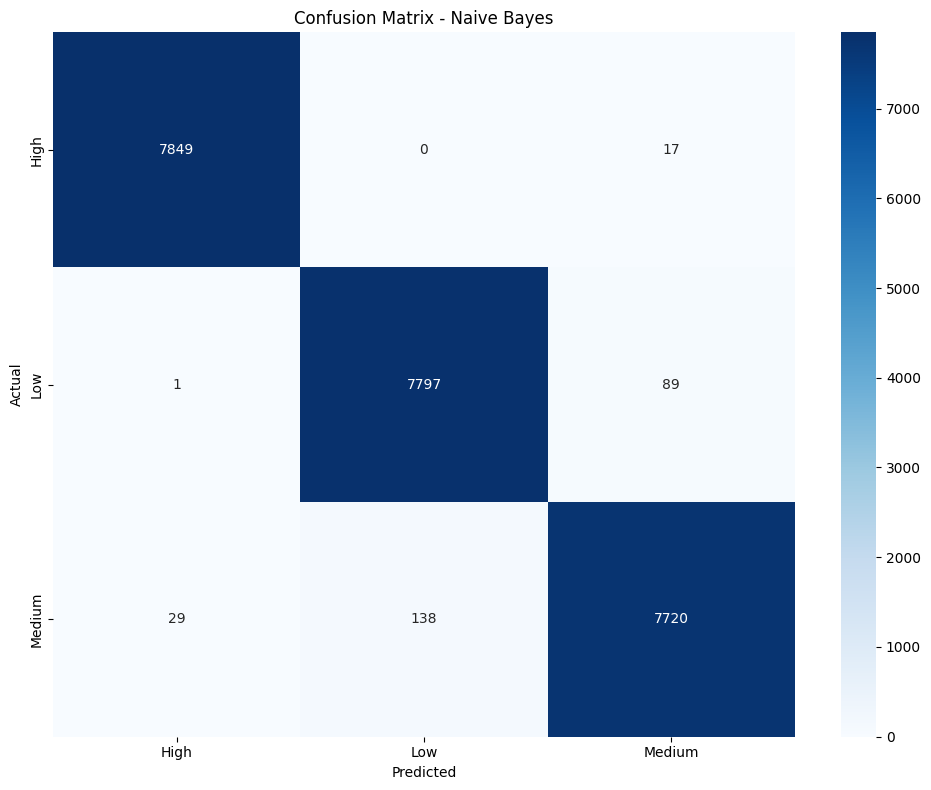

✅ Model saved successfully.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = email_data['Combined_Text']
y = email_data['Email_Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Feature selection 
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

#Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_selected, y_train)

#Predict and Evaluate
y_pred = model.predict(X_test_selected)

print("Column: Cleaned_Message")
print(f"NB: 1,3 UBT - Max:{vectorizer.max_features} - Classification Report:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=model.classes_,
                           columns=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

## Model Buidling - Hybrid Model

#(3) TfidfVectorizer - Uni,Bigram - HM - Cleaned_Message - Acc: %

## Other

In [ ]:
#Identifying common phrases for TFIDF
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

label_filter = None

y_label = email_data if label_filter is None else email_data[email_data['Qwen2.5_Category'] == label_filter]

tfidf = TfidfVectorizer(max_features=1500)  
X_tfidf = tfidf.fit_transform(y_label['Cleaned_Message'])

general_xy_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

print("Top TF-IDF Features::\n", general_xy_tfidf_df.sum(axis=0).sort_values(ascending=False))

Top TF-IDF Features::
 new            8368.915767
the            6773.902936
review         4886.102995
is             4858.803745
project        4751.164244
                  ...     
carr            119.915210
ectrt           106.140916
binding         105.343012
enforceable      98.898773
estoppel         94.259354
Length: 1500, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Separate original and synthetic data
original_mask = email_data.index < 40000  # Based on your original data size
synthetic_mask = ~original_mask

# Create validation sets
X = email_data['Combined_Text']
y = email_data['Email_Priority']

# Split original data for validation
X_orig = X[original_mask]
y_orig = y[original_mask]

X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    X_orig, y_orig, test_size=0.2, stratify=y_orig, random_state=42
)

# Your existing vectorizer setup
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3
)

# Your existing feature selection
selector = SelectKBest(chi2, k=1000)

# Train on mixed data, test on pure original data
X_train_tfidf = vectorizer.fit_transform(X_orig_train)
X_test_tfidf = vectorizer.transform(X_orig_test)

X_train_selected = selector.fit_transform(X_train_tfidf, y_orig_train)
X_test_selected = selector.transform(X_test_tfidf)

# Train model
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_selected, y_orig_train)

# Evaluate on pure original data
y_pred = model.predict(X_test_selected)
print("\nPerformance on Pure Original Data:")
print("Accuracy:", accuracy_score(y_orig_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_orig_test, y_pred))


Performance on Pure Original Data:
Accuracy: 0.9125

Classification Report:
              precision    recall  f1-score   support

        High       0.05      0.30      0.09        23
         Low       0.10      0.68      0.18        91
      Medium       0.99      0.92      0.95      7886

    accuracy                           0.91      8000
   macro avg       0.38      0.63      0.41      8000
weighted avg       0.98      0.91      0.94      8000



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score

# Assuming email_data is your DataFrame with 'Combined_Text' and 'Email_Priority' columns
X = email_data['Combined_Text']
y = email_data['Email_Priority']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Feature selection
selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

# Create and train calibrated model
calibrated_model = CalibratedClassifierCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=5
)

# Train the calibrated model
calibrated_model.fit(X_train_selected, y_train)

# Get probability predictions
y_pred_proba = calibrated_model.predict_proba(X_test_selected)
y_pred = calibrated_model.predict(X_test_selected)

# Print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9950930626057529

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



In [9]:
import numpy as np
from sklearn.calibration import CalibratedClassifierCV

# Calibrate your model to get probability estimates
calibrated_model = CalibratedClassifierCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=5
)

# Train on the selected features
calibrated_model.fit(X_train_selected, y_train)

# Get probability predictions
y_pred_proba = calibrated_model.predict_proba(X_test_selected)
y_pred = calibrated_model.predict(X_test_selected)

# Apply confidence threshold
confidence_threshold = 0.8
prediction_confidence = np.max(y_pred_proba, axis=1)
high_confidence_mask = prediction_confidence >= confidence_threshold

# Evaluate high-confidence predictions
high_conf_predictions = y_pred[high_confidence_mask]
high_conf_true = y_test[high_confidence_mask]

print("\nHigh Confidence Predictions (threshold >= 0.8):")
print(f"Number of high confidence predictions: {len(high_conf_predictions)}")
print(f"Percentage of high confidence: {(len(high_conf_predictions)/len(y_pred))*100:.2f}%")
print("\nClassification Report (High Confidence Only):")
print(classification_report(high_conf_true, high_conf_predictions))


High Confidence Predictions (threshold >= 0.8):
Number of high confidence predictions: 23605
Percentage of high confidence: 99.85%

Classification Report (High Confidence Only):
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7874
      Medium       0.99      1.00      0.99      7865

    accuracy                           1.00     23605
   macro avg       1.00      1.00      1.00     23605
weighted avg       1.00      1.00      1.00     23605



In [11]:
import numpy as np
import pandas as pd

def analyze_errors(y_true, y_pred, X_text, confidence_scores=None):
    # Convert to numpy arrays if they're not already
    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)
    
    # Find misclassified samples
    misclassified_idx = np.where(y_true_array != y_pred_array)[0]
    
    print(f"\nTotal misclassified samples: {len(misclassified_idx)}")
    print("\nDetailed Error Analysis:")
    
    # Create error distribution DataFrame
    error_df = pd.DataFrame({
        'True': y_true_array[misclassified_idx],
        'Predicted': y_pred_array[misclassified_idx]
    })
    
    error_distribution = pd.crosstab(
        error_df['True'],
        error_df['Predicted'],
        margins=True
    )
    
    print("\nError Distribution:")
    print(error_distribution)
    
    # Convert X_text to series if it's not already
    X_text_series = pd.Series(X_text) if not isinstance(X_text, pd.Series) else X_text
    
    # Analyze specific examples
    print("\nExample Misclassifications:")
    for i, idx in enumerate(misclassified_idx[:5]):  # Show first 5 errors
        print("\n" + "="*80)
        print(f"Example {i+1}:")
        print(f"Text: {str(X_text_series.iloc[idx])[:200]}...")  # Show first 200 chars
        print(f"True label: {y_true_array[idx]}")
        print(f"Predicted: {y_pred_array[idx]}")
        if confidence_scores is not None:
            print(f"Confidence: {confidence_scores[idx]:.3f}")

# Calculate prediction confidence scores (if using probability predictions)
prediction_confidence = None
if hasattr(calibrated_model, 'predict_proba'):
    y_pred_proba = calibrated_model.predict_proba(X_test_selected)
    prediction_confidence = np.max(y_pred_proba, axis=1)

# Use the function
analyze_errors(
    y_test,
    y_pred,
    X_test,  # This should be your original text data, not the vectorized features
    confidence_scores=prediction_confidence
)


Total misclassified samples: 116

Detailed Error Analysis:

Error Distribution:
Predicted  Low  Medium  All
True                       
High         0      17   17
Low          0      87   87
Medium      12       0   12
All         12     104  116

Example Misclassifications:

Example 1:
Text: conversation lavo speak lavo today different matter mention great help manage world complementary overall count hand happen rac job rick...
True label: Low
Predicted: Medium
Confidence: 0.980

Example 2:
Text: entouch deadline business highlight news week entouch newsletter submit noon today kathie grabstald...
True label: High
Predicted: Medium
Confidence: 0.936

Example 3:
Text: good evening robin...
True label: Low
Predicted: Medium
Confidence: 0.930

Example 4:
Text: ee xmas party thank take time stop speak wife ees christmas party realize numerous people meet greet sincere say enron leadership grow successful innovative company world personally look forward major...
True label: Low
Predicte

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# Create a pipeline with your preprocessing steps
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 3),
        stop_words='english',
        min_df=3
    )),
    ('selector', SelectKBest(chi2, k=1000)),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Perform stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Fit and evaluate the pipeline
    pipeline.fit(X_train_fold, y_train_fold)
    score = pipeline.score(X_val_fold, y_val_fold)
    cv_scores.append(score)
    
    print(f"\nFold {fold+1} Performance:")
    y_val_pred = pipeline.predict(X_val_fold)
    print(classification_report(y_val_fold, y_val_pred))

print(f"\nCross-validation scores: {cv_scores}")
print(f"Average CV score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


Fold 1 Performance:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      0.99      7887
      Medium       0.99      1.00      0.99      7887

    accuracy                           0.99     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       0.99      0.99      0.99     23640


Fold 2 Performance:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7866
         Low       1.00      0.99      1.00      7886
      Medium       0.99      1.00      0.99      7887

    accuracy                           1.00     23639
   macro avg       1.00      1.00      1.00     23639
weighted avg       1.00      1.00      1.00     23639


Fold 3 Performance:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7867
         Low       1.00      0.99      0.99      7886
      Medium